# **Final for CS 133 notebook**

Created by: ____Geonho Lee ___  
SJSU ID: ____ 017345146 ___   
Last updated: ____ 12/15/2025 ___


### **Scenerio and Goal**:
You have been hired at a winery in Portugal. The winery has collected a seies of physiochemical measurements related to red and white vinho verde wine samples [Cortez et al., 2009](http://www3.dsi.uminho.pt/pcortez/wine/). Your goal is to determine which physicochemical tests to use to model wine quality best.

In this notebook you will be performing:
1. Exploratory data analysis to understand the data
2. Pre-process to clean and prepare of the data for modeling
3. Select a modeling method to understand wine quality and make actionable recommendation to the winery.

**Deliverable**  
You will work in this notebook for all the coding tasks and submit a separate report summarizing your findings.
  

### Data:
There are two datasets. You are expected to use both datasets in your analysis and modeling.  

Dataset is from [UCI Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)  

Sensory features (based on physicochemical tests):
- `fixed acidity`: continuous
- `volatile acidity`: continuous
- `residual sugar`: continuous
- `chlorides`: continuous
- `free sulfur dioxide`: continuous
- `total sulfur dioxide`: continuous
- `density`: continuous
- `pH`: continuous
- `alcohol`: continuous  

Additional variables
- `quality` - integer between 0 and 10 based on sensory data

In [1]:
# Before we start, I would like to organize all the imports used in this project here.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
redwine_fp = 'https://raw.githubusercontent.com/CS133-DataVisualization/F25-classfiles/refs/heads/main/Final/winequality-red.csv'
whitewine_fp = 'https://raw.githubusercontent.com/CS133-DataVisualization/F25-classfiles/refs/heads/main/Final/winequality-white.csv'

## Part 1: Data Exploration
In this first part, you are ask to examine the data to understand the distribution, the relationship between features, and how to distinguish between red versus white wine. Some things that you should be considering is the datatype for each feature, if there are missing data, are there duplicate entries, is the data is balanced, are there outliers, and if all the features are relevant.  

Provide **three** meaningful questions to help you understand the data. For each question:
- Generate a plot that includes clear axis label, a meaningful title, clearly label data points
- In your report include your plots and write 3-5 sentences summarizing your interpretations.
  
#### Deliverables:
- Three questions with corresponding plots and intepretation (eg., patterns, differences, potential data quality issues)
- Information on findings including
  - value and ranges of features
  - distribution of features (skewed, normal)
  - how features relate to quality
  - red versus white wine comparison

In [3]:
red_df = pd.read_csv(redwine_fp, sep=';')
white_df = pd.read_csv(whitewine_fp, sep=';')

In [4]:
red_df['wine_type'] = 'red'
white_df['wine_type'] = 'white'

In [5]:
print("Red wine shape:", red_df.shape)
print("White wine shape:", white_df.shape)

Red wine shape: (1599, 13)
White wine shape: (4898, 13)


In [6]:
print(red_df.info())
print(white_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  wine_type             1599 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 162.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 ent

In [7]:
print("Red wine missing values:")
print(red_df.isna().sum())

print("\nWhite wine missing values:")
print(white_df.isna().sum())

Red wine missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

White wine missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


In [8]:
print("Red wine duplicated rows:", red_df.duplicated().sum())
print("White wine duplicated rows:", white_df.duplicated().sum())

Red wine duplicated rows: 240
White wine duplicated rows: 937


In [9]:
print("Red wine quality distribution:")
print(red_df['quality'].value_counts().sort_index())

print("\nWhite wine quality distribution:")
print(white_df['quality'].value_counts().sort_index())

Red wine quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

White wine quality distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


# Does alcohol content show a clear relationship with wine quality, and does this relationship differ between red and white wines?

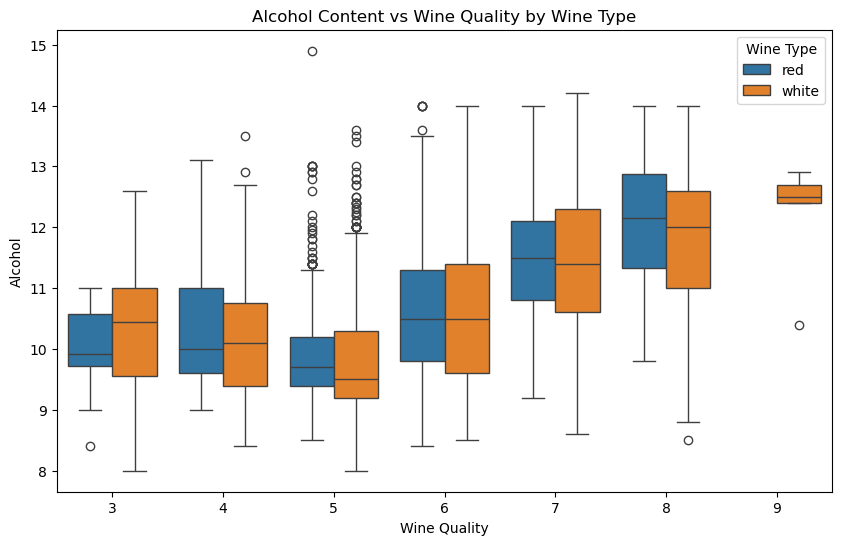

In [10]:
combined_df = pd.concat([red_df, white_df], ignore_index=True)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=combined_df,
    x='quality',
    y='alcohol',
    hue='wine_type'
)
plt.title('Alcohol Content vs Wine Quality by Wine Type')
plt.xlabel('Wine Quality')
plt.ylabel('Alcohol')
plt.legend(title='Wine Type')
plt.show()

Alcohol content generally increases as wine quality increases for both red and white wines.
Higher-quality wines tend to have higher median alcohol levels, especially noticeable in white wines.
The relationship appears stronger for white wine, where alcohol content shows a clearer upward trend across quality scores.
This suggests alcohol may be an important predictor of wine quality, particularly for white wines.

# How does volatile acidity relate to wine quality, and is its effect consistent across red and white wines?

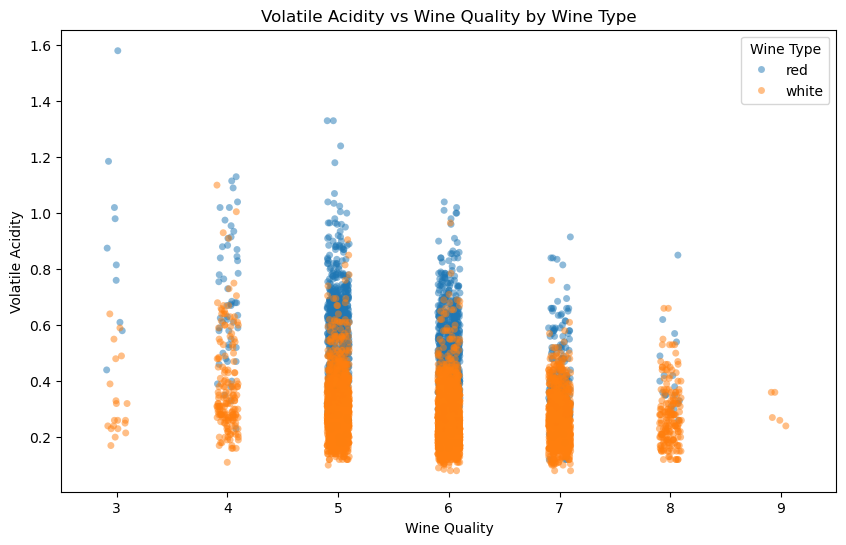

In [11]:
plt.figure(figsize=(10,6))
sns.stripplot(
    data=combined_df,
    x='quality',
    y='volatile acidity',
    hue='wine_type',
    jitter=True,
    alpha=0.5
)
plt.title('Volatile Acidity vs Wine Quality by Wine Type')
plt.xlabel('Wine Quality')
plt.ylabel('Volatile Acidity')
plt.legend(title='Wine Type')
plt.show()

Volatile acidity tends to decrease as wine quality increases, indicating a negative relationship with quality.
This trend is more pronounced in red wines, where lower-quality wines show higher and more variable volatile acidity values.
White wines generally have lower volatile acidity across all quality levels.
These patterns suggest volatile acidity is an important factor in distinguishing lower- from higher-quality wines.

# Are there systematic differences in physicochemical properties between red and white wines that may help distinguish them?

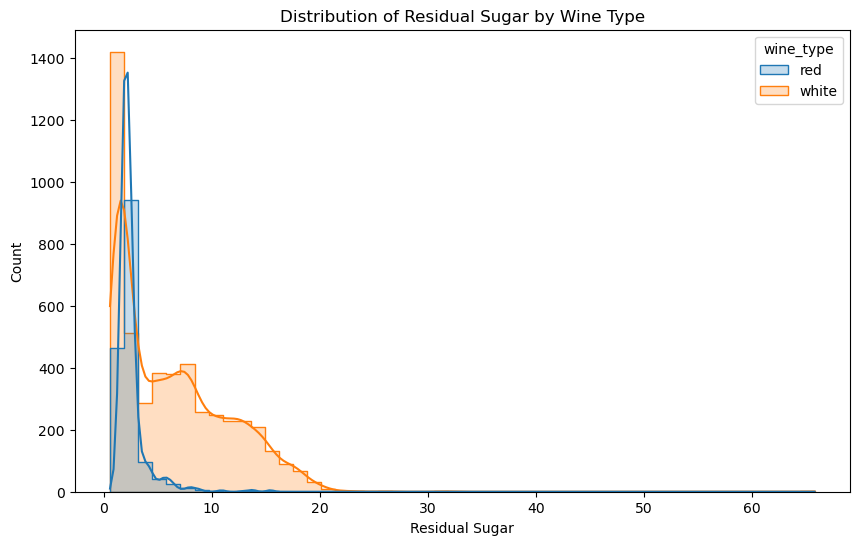

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=combined_df,
    x='residual sugar',
    hue='wine_type',
    bins=50,
    kde=True,
    element='step'
)
plt.title('Distribution of Residual Sugar by Wine Type')
plt.xlabel('Residual Sugar')
plt.ylabel('Count')
plt.show()

White wines tend to have significantly higher residual sugar values compared to red wines, with a strongly right-skewed distribution.
Red wines show a much narrower range of residual sugar, indicating more consistency in this feature.
The large difference in distribution suggests residual sugar is a strong distinguishing feature between wine types.
This characteristic may also influence how quality is perceived differently for red versus white wines.

## Part 2: Pre-processing data

An essential step in building a model is to transform messy, raw data into a clean and well structured dataset ready for modeling. This step including handling missing values, outliers, and inconsistent formats. Explain your reasoning for how you clean the data, any transforming you apply (encoding and scaling), what feature engineering you took to prepare your dataset so that in the next step you can boost the model's accuracy, efficiency and reliability.

#### Deliverable
- How you handle your data to address issues such as missing values, duplicate values, and potential outliers
- Feature engineering steps including creation of new variables or converting of existing variables into new varaibles
- Any features that you scaled or transformed
- How you set up your train/test split including proportion and if split was stratified
- Reasonings behind your decisions for pre-processing

In [13]:
print(red_df.isna().sum().sum())
print(white_df.isna().sum().sum())

0
0


In [14]:
red_df_clean = red_df.drop_duplicates().reset_index(drop=True)
white_df_clean = white_df.drop_duplicates().reset_index(drop=True)

print("Red wine after duplicate removal:", red_df_clean.shape)
print("White wine after duplicate removal:", white_df_clean.shape)

Red wine after duplicate removal: (1359, 13)
White wine after duplicate removal: (3961, 13)


In [15]:
red_df_clean['wine_type_encoded'] = 0
white_df_clean['wine_type_encoded'] = 1

In [16]:
processed_df = pd.concat(
    [red_df_clean, white_df_clean],
    ignore_index=True
)

processed_df.shape

(5320, 14)

In [17]:
X = processed_df.drop(columns=['quality', 'wine_type'])
y = processed_df['quality']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print(X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape)

(4256, 12) (1064, 12) (4256,) (1064,)


## Part 3: ML models
Now that your data is cleaned and split into training and test sets, you are asked to select two different ML models to predict wine quality. Explain and justify why you selected these two models for of problem you are solving.
   
For each chosen model, explain briefly how you train the model, fine-tune the hyperparameters, and evaluate the performance.

#### Deliverable
- Your training method inluding validation splits and tuning of hyperparameters. Explain which hyperparameters you tried and how you choose the "best" settings
- Model evaluation and which metics you use to understand the output from the model
- Address which model performed better given your metrics
- Were there any signs of over- or underfitting?
- Which of the features was most influential in predicting wine quality?
- Are the model results consistent with your EDA findings from Part 1?
- Your recommendation to the winery:
  - Which model is best to predict wine quality?
  - Main insights on which physiochemical measurements are most important to consider in wine quality
  - What are some limitations that winery shoud consider when trying to understand wine quality.


In [21]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Accuracy: 0.5338345864661654
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.75      0.07      0.13        41
           5       0.57      0.61      0.59       350
           6       0.52      0.67      0.58       465
           7       0.48      0.23      0.31       171
           8       0.00      0.00      0.00        30
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1064
   macro avg       0.33      0.23      0.23      1064
weighted avg       0.52      0.53      0.50      1064



In [22]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best RF Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV Accuracy: 0.5768327067669173


In [23]:
best_rf = grid.best_estimator_

y_pred_rf = best_rf.predict(X_test_scaled)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


Random Forest Test Accuracy: 0.5639097744360902
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.60      0.07      0.13        41
           5       0.60      0.68      0.64       350
           6       0.54      0.66      0.59       465
           7       0.54      0.30      0.38       171
           8       1.00      0.07      0.12        30
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1064
   macro avg       0.47      0.25      0.27      1064
weighted avg       0.57      0.56      0.54      1064



In [24]:
print("RF Train Accuracy:", best_rf.score(X_train_scaled, y_train))
print("RF Test Accuracy:", best_rf.score(X_test_scaled, y_test))

RF Train Accuracy: 1.0
RF Test Accuracy: 0.5639097744360902


In [25]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(8)

alcohol                 0.127046
density                 0.100400
volatile acidity        0.097121
total sulfur dioxide    0.090416
chlorides               0.088190
sulphates               0.086934
free sulfur dioxide     0.086482
residual sugar          0.083432
dtype: float64

In this project, two different machine learning models were used to predict wine quality: Logistic Regression and Random Forest. Logistic Regression was chosen as a baseline model because of its simplicity, efficiency, and interpretability, allowing for an initial understanding of how physicochemical features relate to wine quality. Random Forest was selected as a more advanced, non-linear model capable of capturing complex interactions between features. The data was split into training and testing sets using an 80/20 stratified split to preserve the original quality distribution. Logistic Regression achieved a test accuracy of approximately 53%, while Random Forest achieved a higher test accuracy of approximately 56% after hyperparameter tuning using GridSearchCV with stratified cross-validation. This indicates that Random Forest performed better overall. However, Random Forest showed clear signs of overfitting, as it achieved perfect accuracy on the training set but lower accuracy on the test set. Feature importance analysis from the Random Forest model showed that alcohol content was the most influential feature, followed by density, volatile acidity, and sulfur-related variables. These results are consistent with the EDA findings, which showed a positive relationship between alcohol level and wine quality. Based on these results, Random Forest is recommended as the better model for predicting wine quality, while acknowledging limitations such as subjective quality labels, class imbalance in rare quality scores, limited feature scope, and potential overfitting.


In [26]:
#final run before uploading to git.